# Sudoku Rule-Based Loss — Demo

Pedagogical walk-through of the auxiliary *rule loss* proposed for the MDM Sudoku baseline (Ye et al. 2024).

**Research question:** does a differentiable, rule-based auxiliary loss improve the sample efficiency of a masked diffusion model trained to solve Sudoku?

The rule loss penalizes the model when its predicted digit distributions are *likely to produce duplicates* within any Sudoku group (row, column, 3×3 box). It is **unsupervised** — it does not see the ground-truth solution. The supervised signal is provided separately by the standard MDM cross-entropy loss.

This notebook walks through:
1. Load a real puzzle from the training dataset.
2. Mask it the same way training does (`q_sample` at timestep `t`).
3. Fabricate a per-cell distribution as a model might produce.
4. Show the formula, compute the loss, and explore edge cases for intuition.

In [1]:
import importlib.util
import json
import random
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset

# Locate the repo root (notebook lives in <repo>/notebooks/).
NB_DIR = Path.cwd()
if (NB_DIR / 'src').exists():
    REPO_ROOT = NB_DIR
elif (NB_DIR.parent / 'src').exists():
    REPO_ROOT = NB_DIR.parent
else:
    raise RuntimeError('Could not locate repo root (looked for ./src and ../src)')

# Load the two codebase modules we need *directly by file path*, bypassing
# llmtuner's package __init__ which pulls in training-only deps (peft, accelerate, …).
# This keeps the notebook runnable on a minimal env: torch + matplotlib + datasets + transformers.
def _load_module(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

_tok_mod = _load_module(
    'custom_tokenizer',
    REPO_ROOT / 'src/llmtuner/tuner/core/custom_tokenizer.py',
)
CustomTokenizer = _tok_mod.CustomTokenizer

_rl_mod = _load_module(
    'rule_loss',
    REPO_ROOT / 'src/llmtuner/tuner/mdm/rule_loss.py',
)
compute_rule_loss     = _rl_mod.compute_rule_loss
_sudoku_group_indices = _rl_mod._sudoku_group_indices
digit_token_ids       = _rl_mod.digit_token_ids

DATA_DIR = REPO_ROOT / 'data'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
T = 20  # diffusion steps (paper default)

print(f'repo root: {REPO_ROOT}')
print(f'data dir:  {DATA_DIR}')

repo root: /Users/leonardebinger/Desktop/Dateien/Bildung/AI & Data Science M.Sc./4 – SS 26/Lab Rotations/Sudoku/diffusion-vs-ar
data dir:  /Users/leonardebinger/Desktop/Dateien/Bildung/AI & Data Science M.Sc./4 – SS 26/Lab Rotations/Sudoku/diffusion-vs-ar/data


In [2]:
# Load the Sudoku training dataset exactly like the training code does.
info = json.load(open(DATA_DIR / 'dataset_info.json'))
entry = info['sudoku_train']
fname = entry['file_name']
path = str(DATA_DIR / fname)
ext = fname.rsplit('.', 1)[-1].lower()
type_map = {'json': 'json', 'jsonl': 'json', 'csv': 'csv', 'txt': 'text', 'tsv': 'csv'}

ds = load_dataset(type_map[ext], data_files=path, split='train')
print(f'loaded {len(ds):,} puzzles from {fname}')
print(f'original columns: {ds.column_names}')

# The training loader renames non-canonical column names to 'prompt' / 'response'
# using the "columns" mapping in dataset_info.json. Mirror that here so the rest of
# the notebook can use sample['prompt'] / sample['response'].
columns_map = entry.get('columns', {})
for canonical in ('prompt', 'response'):
    src_name = columns_map.get(canonical, canonical)
    if src_name != canonical and src_name in ds.column_names:
        ds = ds.rename_column(src_name, canonical)
print(f'after rename:     {ds.column_names}')

idx = random.randrange(len(ds))
sample = ds[idx]
prompt = sample['prompt']
response = sample['response']
print(f'\nsample idx: {idx}')
print(f'prompt   (81 digits, 0 = blank):  {prompt}')
print(f'response (81 digits, 1-9):        {response}')

loaded 100,000 puzzles from sudoku_train.csv
original columns: ['quizzes', 'solutions']
after rename:     ['prompt', 'response']

sample idx: 83810
prompt   (81 digits, 0 = blank):  010738002007006003060500040900850030130400059206000800040000007003601080805300091
response (81 digits, 1-9):        419738562587246913362519748974852136138467259256193874641985327793621485825374691


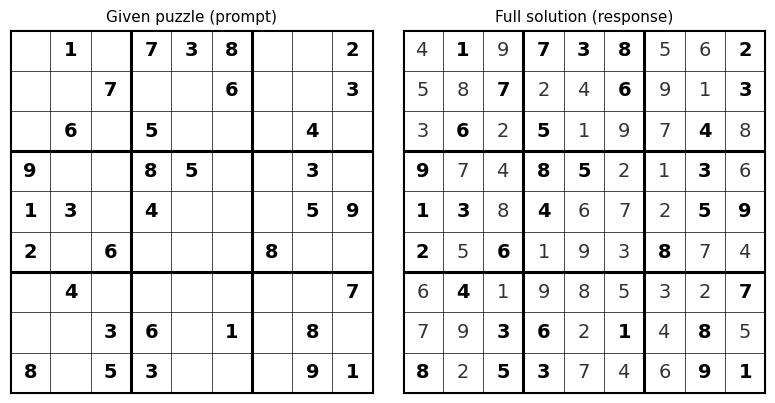

In [3]:
def parse81(s):
    """Parse an 81-char digit string into a list of 81 ints."""
    return [int(c) for c in s]

def render_grid(grid, ax=None, title=None, givens_mask=None, masked_mask=None):
    """9x9 Sudoku grid with thick 3x3 box lines.
    - grid: length-81 list of ints (0 = blank).
    - givens_mask[i]=True  → bold (a given from the prompt).
    - masked_mask[i]=True  → grey fill with a dash (currently [MASK]).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(0, 9); ax.set_ylim(0, 9); ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for i in range(81):
        r, c = i // 9, i % 9
        is_masked = masked_mask is not None and bool(masked_mask[i])
        is_given  = givens_mask is not None and bool(givens_mask[i])
        if is_masked:
            ax.add_patch(plt.Rectangle((c, r), 1, 1, facecolor='lightgrey', edgecolor='none'))
            ax.text(c + 0.5, r + 0.5, '—', ha='center', va='center', fontsize=14, color='dimgrey')
        elif grid[i] != 0:
            fw  = 'bold' if is_given else 'normal'
            col = 'black' if is_given else '#333'
            ax.text(c + 0.5, r + 0.5, str(grid[i]), ha='center', va='center',
                    fontsize=14, fontweight=fw, color=col)
    for k in range(10):
        lw = 2.2 if k % 3 == 0 else 0.5
        ax.plot([k, k], [0, 9], 'k-', linewidth=lw)
        ax.plot([0, 9], [k, k], 'k-', linewidth=lw)
    if title:
        ax.set_title(title, fontsize=11)

prompt_grid   = parse81(prompt)
response_grid = parse81(response)
givens        = [v != 0 for v in prompt_grid]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
render_grid(prompt_grid,   ax=axes[0], title='Given puzzle (prompt)',   givens_mask=givens)
render_grid(response_grid, ax=axes[1], title='Full solution (response)', givens_mask=givens)
plt.tight_layout(); plt.show()

t = 10  →  per-cell mask probability = 0.55  →  38 / 81 cells masked


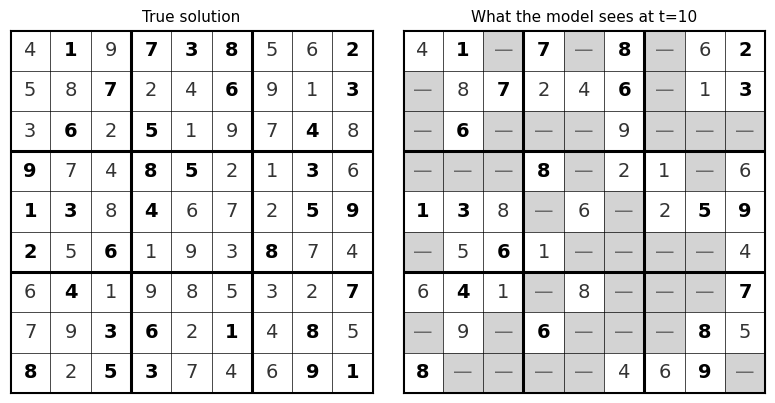

In [4]:
# Apply the same masking the MDM training loop uses (`q_sample`).
# Pick a diffusion timestep t ∈ [0, T-1]. Each of the 81 target cells is masked
# independently with probability (t+1)/T. Prompt cells (givens) are never masked.
t = 10  # adjust: 0 = almost no masking; T-1 = almost all masked

torch.manual_seed(SEED)
mask_prob = (t + 1) / T
rand_u = torch.rand(81)
mask_selector = (rand_u < mask_prob)

masked_grid = list(response_grid)
for i in range(81):
    if mask_selector[i]:
        masked_grid[i] = 0  # 0 stands in for [MASK] in the display

print(f't = {t}  →  per-cell mask probability = {mask_prob:.2f}  '
      f'→  {int(mask_selector.sum())} / 81 cells masked')

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
render_grid(response_grid, ax=axes[0], title='True solution', givens_mask=givens)
render_grid(masked_grid,   ax=axes[1], title=f'What the model sees at t={t}',
            givens_mask=givens, masked_mask=mask_selector.tolist())
plt.tight_layout(); plt.show()

probs shape: (81, 9)  (per cell, over digits 1..9)
row sums (should all be 1): min=1.000000, max=1.000000


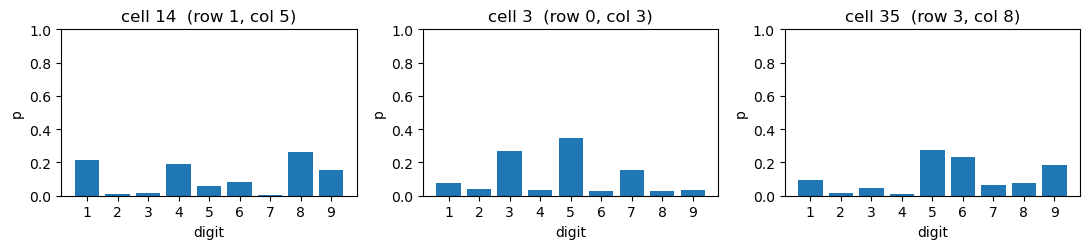

In [5]:
# Pretend the model outputs a distribution over digits 1..9 at each of the 81 cells.
# Generate a random (but proper) per-cell distribution. Shape: [81, 9].
torch.manual_seed(SEED + 1)
probs = torch.softmax(torch.randn(81, 9), dim=-1)  # [81, 9]
print(f'probs shape: {tuple(probs.shape)}  (per cell, over digits 1..9)')
print(f'row sums (should all be 1): min={probs.sum(-1).min():.6f}, max={probs.sum(-1).max():.6f}')

sample_cells = random.sample(range(81), 3)
fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
for ax, ci in zip(axes, sample_cells):
    ax.bar(range(1, 10), probs[ci].numpy())
    ax.set_title(f'cell {ci}  (row {ci // 9}, col {ci % 9})')
    ax.set_xticks(range(1, 10)); ax.set_xlabel('digit'); ax.set_ylabel('p')
    ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## The rule loss — formula

Let $p_i \in \Delta^9$ be the model's predicted distribution over digits $1,\ldots,9$ at cell $i$ (for $i = 0, \ldots, 80$). Let $\mathcal{G}$ be the set of 27 Sudoku groups: 9 rows, 9 columns, 9 $3{\times}3$ boxes. Each group $g \in \mathcal{G}$ contains 9 cells.

**Expected number of duplicate pairs** in group $g$:

$$
\mathbb{E}\bigl[\text{collisions}_g\bigr] \;=\; \sum_{\substack{i,j\in g\\i<j}} \sum_{v=1}^{9} p_i(v)\, p_j(v) \;=\; \sum_{\substack{i,j\in g\\i<j}} \langle p_i, p_j \rangle
$$

Each group has $\binom{9}{2} = 36$ pairs and there are $|\mathcal{G}| = 27$ groups, so the total number of pairs is $972$. We normalize:

$$
\boxed{\;\mathcal{L}_{\text{rule}} \;=\; \frac{1}{972} \sum_{g \in \mathcal{G}} \mathbb{E}\bigl[\text{collisions}_g\bigr] \;\in\; [0,\, 1]\;}
$$

**Equivalent rank-1 form** (what the code actually computes, mathematically identical):

$$
\sum_{i<j} \langle p_i, p_j \rangle \;=\; \tfrac{1}{2}\!\left(\Bigl\|{\textstyle\sum_i p_i}\Bigr\|^2 - \sum_i \|p_i\|^2\right).
$$

**Cardinal values**:
- **Valid solved Sudoku** (each cell one-hot, no duplicates in any group): $\mathcal{L}_{\text{rule}} = 0$.
- **Uniform** (each cell $p_i = (1/9, \ldots, 1/9)$): $\mathcal{L}_{\text{rule}} = 1/9 \approx 0.111$.
- **All 9 cells in some group one-hot on the same digit**: that group contributes $1.0$.

The rule loss is **unsupervised** — it reads only $p$, never the ground-truth solution. It measures *Sudoku validity*, not *correctness*. Correctness remains the job of the standard MDM cross-entropy loss.

In [6]:
# Pedagogical: self-contained implementation of the formula, 6 lines, using the
# group-index helper imported from the codebase.
GROUPS = _sudoku_group_indices()  # [27, 9]

def rule_loss_from_probs(probs: torch.Tensor) -> torch.Tensor:
    """probs: [81, 9] per-cell distribution over digits 1..9."""
    p_g            = probs[GROUPS, :]              # [27, 9, 9]  gather cells into groups
    sum_p          = p_g.sum(dim=1)                # [27, 9]     Σ_i p_i per group
    sum_sq         = (sum_p * sum_p).sum(-1)       # [27]        ‖Σ_i p_i‖²
    self_sq        = (p_g * p_g).sum(-1).sum(-1)   # [27]        Σ_i ‖p_i‖²
    expected_pairs = 0.5 * (sum_sq - self_sq)      # [27]
    return (expected_pairs / 36.0).mean()          # per-pair collision, averaged over 27 groups

# Identical math to `compute_rule_loss` in src/llmtuner/tuner/mdm/rule_loss.py.

In [7]:
# Compute on the random example...
loss_random = rule_loss_from_probs(probs)
print(f'rule_loss on random probs:   {loss_random.item():.4f}   (expected ~1/9 ≈ {1/9:.4f})')

# ...then cross-check against the production function `compute_rule_loss`. It takes the
# full [B, L, V] logits tensor with src_mask, so we construct one that encodes our 81x9 probs.
tokenizer = CustomTokenizer.from_pretrained(str(REPO_ROOT / 'model_config_tiny'))
digit_ids = digit_token_ids(tokenizer)  # token ids for '1'..'9' (= 6..14)
V = tokenizer.vocab_size                 # 31
L = 164

logits = torch.full((1, L, V), -1e4)                 # non-digit channels → ~0 probability
for cell_idx in range(81):
    pos = 82 + cell_idx                               # 81 prompt chars + [SEP], then target cells
    for k, tok_id in enumerate(digit_ids):
        logits[0, pos, tok_id] = probs[cell_idx, k].clamp(min=1e-30).log()

src_mask = torch.zeros(1, L, dtype=torch.bool)
src_mask[0, :82] = True                               # prompt + [SEP]

loss_codebase = compute_rule_loss(logits, src_mask, tokenizer)
print(f'compute_rule_loss (codebase): {loss_codebase.item():.4f}')

gap = abs(loss_random.item() - loss_codebase.item())
print(f'\ngap: {gap:.2e}')
assert gap < 1e-5, 'pedagogical formula and production code disagree!'
print('✓ formulas agree')

rule_loss on random probs:   0.1104   (expected ~1/9 ≈ 0.1111)
compute_rule_loss (codebase): 0.1104

gap: 0.00e+00
✓ formulas agree


case                                                      rule_loss    expected
--------------------------------------------------------------------------------
Solved Sudoku (one-hot on true values)                       0.0000      0.0000
Uniform 1/9 per cell                                         0.1111      0.1111
All cells one-hot on digit 1                                 1.0000      1.0000
Confident-but-wrong (cyclic digit shift)                     0.0000      0.0000
Uniform over {1, 2, 3} (zero elsewhere)                      0.3333      0.3333
Random one-hot per cell (ignoring constraints)               0.1060      0.1111
Row 0 forced to all 1s (rest valid solution)                 0.0607           —


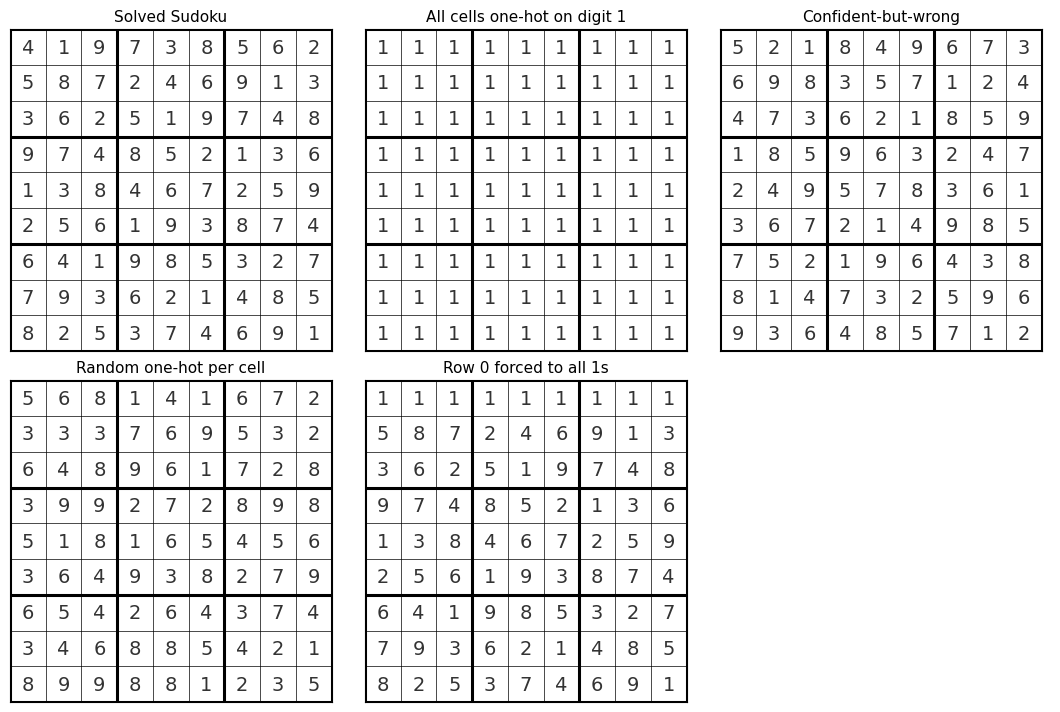

In [8]:
# Toy cases for intuition. For each: compute rule_loss, compare to theory, optionally render.
def one_hot(digits):
    """digits: length-81 ints 1..9  →  one-hot tensor [81, 9]."""
    p = torch.zeros(81, 9)
    for i, d in enumerate(digits):
        p[i, d - 1] = 1.0
    return p

results = []  # (label, computed_loss, expected_loss_or_None, grid_for_display_or_None)

# 1. Valid solved Sudoku (one-hot on the true response).
p_sol = one_hot(response_grid)
results.append(('Solved Sudoku (one-hot on true values)',
                rule_loss_from_probs(p_sol).item(), 0.0, response_grid))

# 2. Uniform 1/9 at every cell.
p_uniform = torch.full((81, 9), 1/9)
results.append(('Uniform 1/9 per cell',
                rule_loss_from_probs(p_uniform).item(), 1/9, None))

# 3. All-same digit (every cell one-hot on digit 1).
p_all_1 = one_hot([1] * 81)
results.append(('All cells one-hot on digit 1',
                rule_loss_from_probs(p_all_1).item(), 1.0, [1] * 81))

# 4. Confident-but-wrong: cyclic digit shift of the solution (still a valid Sudoku, wrong labels).
shifted = [(d % 9) + 1 for d in response_grid]  # 1→2, 2→3, ..., 9→1
p_shifted = one_hot(shifted)
results.append(('Confident-but-wrong (cyclic digit shift)',
                rule_loss_from_probs(p_shifted).item(), 0.0, shifted))

# 5. Uniform over {1, 2, 3} only, zero elsewhere.
p_uniform3 = torch.zeros(81, 9); p_uniform3[:, :3] = 1/3
results.append(('Uniform over {1, 2, 3} (zero elsewhere)',
                rule_loss_from_probs(p_uniform3).item(), 1/3, None))

# 6. Random one-hot per cell, ignoring constraints.
torch.manual_seed(SEED + 2)
random_digits = torch.randint(1, 10, (81,)).tolist()
p_rand_onehot = one_hot(random_digits)
results.append(('Random one-hot per cell (ignoring constraints)',
                rule_loss_from_probs(p_rand_onehot).item(), 1/9, random_digits))

# 7. Row-broken: true solution except row 0 forced to all 1s.
row_broken = list(response_grid)
for c in range(9):
    row_broken[c] = 1
p_rowbroken = one_hot(row_broken)
results.append(('Row 0 forced to all 1s (rest valid solution)',
                rule_loss_from_probs(p_rowbroken).item(), None, row_broken))

# Pretty-print.
print(f"{'case':<55}  {'rule_loss':>10}  {'expected':>10}")
print('-' * 80)
for label, val, exp, _ in results:
    exp_s = f'{exp:.4f}' if exp is not None else '  —'
    print(f'{label:<55}  {val:>10.4f}  {exp_s:>10}')

# Render the toy grids that have a visual (those with a non-None grid).
to_show = [(lbl, grid) for (lbl, _, _, grid) in results if grid is not None]
n = len(to_show)
cols = min(3, n); rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.6 * rows))
axes = np.array(axes).reshape(-1)
for ax, (lbl, grid) in zip(axes, to_show):
    short = lbl.split('(')[0].strip()
    render_grid(grid, ax=ax, title=short)
for ax in axes[len(to_show):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Takeaway

**What the rule loss is**: a differentiable, group-level constraint probability, normalized to $[0, 1]$. It is zero iff the model's predicted distributions describe a *structurally valid* Sudoku — each of the 27 groups has no expected duplicates.

**What it isn't**: a correctness signal. The cyclic-shift example scored $\mathcal{L}_{\text{rule}} \approx 0$ despite being *the wrong answer* for this particular prompt. Validity ≠ correctness — correctness remains the job of the standard MDM cross-entropy loss against the ground-truth digits.

**Integration into training**:

$$
\mathcal{L}_{\text{total}} \;=\; \mathcal{L}_{\text{CE}} \;+\; \lambda \, \mathcal{L}_{\text{rule}}.
$$

Implemented as `RuleLossDiffusionTrainer` — a subclass of `CustomDiffusionTrainer` that reimplements `inner_forward` and adds the rule term. The baseline code path is untouched. The hyperparameter $\lambda$ will be tuned at $N = 10{,}000$ and fixed across dataset sizes.

**Hypothesis**: $\mathcal{L}_{\text{rule}}$ provides gradient on structural validity even when CE has saturated on small-data regimes (where the model memorizes the training set yet fails to generalize) — yielding better sample efficiency. The five-point experimental sweep (baseline vs. rule-loss at $N \in \{1\mathrm{k},\, 3\mathrm{k},\, 10\mathrm{k},\, 30\mathrm{k},\, 100\mathrm{k}\}$) will tell.